# Tarea 2: Análisis Exploratorio de Datos (EDA) y Preprocesamiento
## Laboratorio 1 – Predicción y Clasificación en la Industria Azucarera
### Ingenio Providencia | Algoritmos y Programación III | ICESI 2026

---
## 0. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Estilo global de gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga de Datos

In [2]:
df_reg = pd.read_excel('HISTORICO_SUERTES.xlsx')
df_clf = pd.read_excel('BD_IPSA_1940.xlsx')

print(f'HISTORICO_SUERTES : {df_reg.shape[0]:,} filas × {df_reg.shape[1]} columnas')
print(f'BD_IPSA_1940      : {df_clf.shape[0]:,} filas × {df_clf.shape[1]} columnas')

HISTORICO_SUERTES : 21,027 filas × 85 columnas
BD_IPSA_1940      : 2,187 filas × 21 columnas


---
## 2. Análisis de Valores Nulos – Ambos Datasets

Antes de seleccionar variables, identificamos la calidad real de cada columna. Una variable con >50% de nulos introduce más ruido que señal.

In [3]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
    print(f'\n── {nombre} ──  ({len(resumen)} columnas con nulos de {df.shape[1]} totales)')
    print(resumen.to_string())
    return resumen

nulos_reg = resumen_nulos(df_reg, 'HISTORICO_SUERTES')
nulos_clf = resumen_nulos(df_clf, 'BD_IPSA_1940')


── HISTORICO_SUERTES ──  (58 columnas con nulos de 85 totales)
                           Nulos  Porcentaje (%)
Sum Oscilacion Temp Ciclo  21027          100.00
Fert.Nitrogen.             21027          100.00
Urea 46%                   20304           96.56
NITRAX-S                   20279           96.44
MEZ                        20056           95.38
MicroZinc                  19878           94.54
Boro Granul.               19742           93.89
Sul.Amonio                 19670           93.55
NITO_XTEND                 17348           82.50
Vinaza                     16929           80.51
Humedad Rel Media Ciclo    16497           78.46
Temp. Media 0-3            16497           78.46
Temp Max Ciclo             16497           78.46
Temp. Media Ciclo          16497           78.46
Oscilacion Temp Med 0-3    16497           78.46
Humedad Rel Media 0-3      16497           78.46
Oscilacion Temp Ciclo      16497           78.46
Precipitacion 0_3          16497           78.46
Temp 

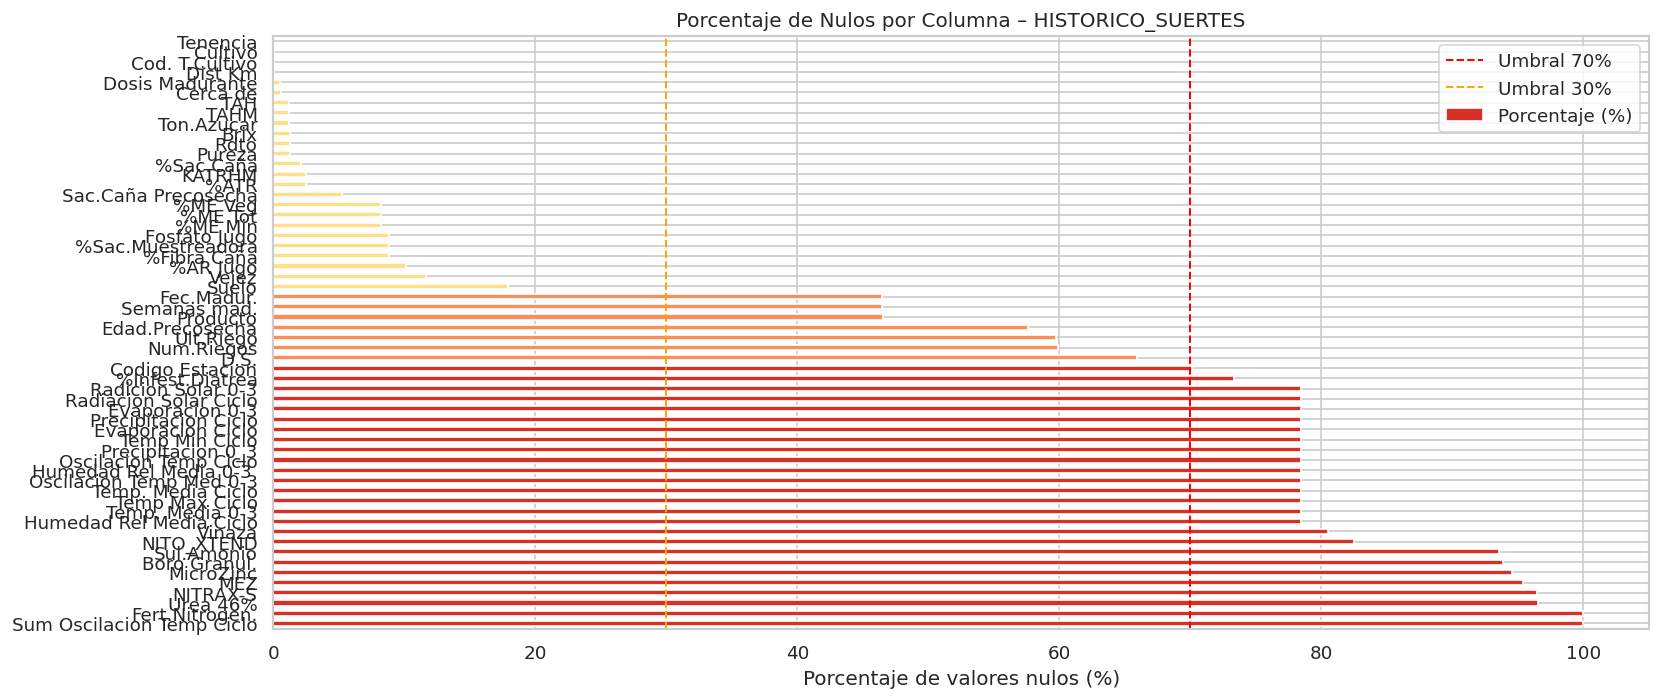

Variables en rojo (>70%): candidatas a eliminar por exceso de datos faltantes.


In [4]:
# Visualización del mapa de nulos para HISTORICO_SUERTES
# Usamos solo columnas con al menos 1 nulo para que sea legible
cols_con_nulos = nulos_reg.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
nulos_reg['Porcentaje (%)'].plot(
    kind='barh', ax=ax,
    color=nulos_reg['Porcentaje (%)'].apply(
        lambda x: '#d73027' if x > 70 else ('#fc8d59' if x > 30 else '#fee08b')
    )
)
ax.axvline(70, color='red', linestyle='--', linewidth=1.2, label='Umbral 70%')
ax.axvline(30, color='orange', linestyle='--', linewidth=1.2, label='Umbral 30%')
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Porcentaje de Nulos por Columna – HISTORICO_SUERTES')
ax.legend()
plt.tight_layout()
plt.show()
print('Variables en rojo (>70%): candidatas a eliminar por exceso de datos faltantes.')

---
## 3. Selección y Justificación de Variables

### 3.1 Dataset HISTORICO_SUERTES – Regresión (TCH y %Sac.Caña)

**Variables DESCARTADAS con justificación:**

| Variable | Razón de descarte |
|---|---|
| `Fert.Nitrogen.`, `Sum Oscilacion Temp Ciclo` | 100% nulos |
| `Urea 46%`, `MEZ`, `Boro Granul.`, `MicroZinc`, `Sul.Amonio`, `NITRAX-S` | >90% nulos |
| `NITO_XTEND`, `Vinaza` | >80% nulos |
| `D.S.`, `%Infest.Diatrea`, `Codigo Estacion` | >70% nulos |
| `Num.Riegos`, `Ult.Riego`, `Edad.Precosecha` | >57% nulos |
| `Fec.Madur.`, `Producto`, `Semanas mad.` | 46.5% nulos (incluimos `Dosis Madurante` y derivamos tiempo de maduración) |
| `Nombre`, `Suerte`, `Hacienda` | Identificadores sin poder predictivo |
| `Cod.Estado #`, `Cod.Estado` | Codificación del estado actual del lote, no del cultivo en sí |
| `TCHM`, `Ton.Azucar`, `Rdto`, `TAH`, `TAHM` | **Data leakage**: derivadas directamente de TCH o %Sac.Caña |
| `Brix`, `Pureza`, `%ATR`, `KATRHM` | **Data leakage**: métricas de calidad del jugo, calculadas post-cosecha junto con %Sac.Caña |
| `%Sac.Muestreadora`, `%Fibra Caña`, `%AR Jugo`, `%ME Min`, `%ME Veg`, `%ME Tot`, `Fosfato Jugo` | Mediciones de laboratorio post-cosecha → leakage |
| `Sac.Caña Precosecha` | Solo útil para predecir %Sac.Caña (leakage parcial, retiramos para evitar sesgo) |
| `TonUltCorte` | Toneladas totales, correlación directa con TCH dado el área |
| Variables Temp./Humedad/Radiación (78.5% nulos) | Exceso de nulos; las lluvias cubren la dimensión climática |
| `F.Siembra`, `F.Ult.Corte` | Fechas crudas; la edad del cultivo (`Edad Ult Cos`) ya las sintetiza |

**Variables SELECCIONADAS:**

In [5]:
# Variables seleccionadas para REGRESIÓN
TARGETS_REG = ['TCH', '%Sac.Caña']

FEATURES_REG = [
    # Agronomía del cultivo
    'Edad Ult Cos',      # Edad en semanas: predictor clave de rendimiento y madurez
    'Variedad',          # Genética del cultivo: afecta directamente TCH y sacarosa
    'Suelo',             # Tipo de suelo: retención de agua y nutrientes
    'Zona',              # Región geográfica: captura microclimatología
    'Tenencia',          # Tipo de tenencia: puede reflejar prácticas agrícolas
    'Vejez',             # Número de cortes: mayor vejez → menor rendimiento (soca/resoca)
    'Destino 1=Semilla', # Si va a semilla el manejo es diferente
    'Cod. T.Cultivo',    # Tipo de cultivo (planta vs soca)
    
    # Logística y cosecha
    'Dist Km',           # Distancia al ingenio: factor logístico relacionado con frescura
    'Tipo Quema',        # Método de quema pre-cosecha: afecta calidad
    'T.Corte',           # Tipo de corte (mecánico/manual): afecta eficiencia
    
    # Insumos de maduración
    'Dosis Madurante',   # Dosis de madurante aplicada: directamente relacionada con %Sac
    
    # Clima / Hidrología (sin nulos)
    'Lluvias (2 Meses Ant.)',   # Lluvia en los 2 meses previos a cosecha (maduración)
    'Lluvias Ciclo',            # Lluvia total del ciclo: crecimiento general
    'Lluvias 0 -3',             # Lluvia primeros 3 meses: establecimiento
    'Lluvias tres a seis',      # Lluvia 3-6 meses: macollamiento
    'Lluvias seis a nueve',     # Lluvia 6-9 meses: elongación
    'Luvias 9 -FC',             # Lluvia 9 meses a cosecha: maduración
    'M3 Riego',                 # Volumen de riego aplicado: complemento hídrico
    'DDUlt.Riego',              # Días desde último riego: estrés hídrico pre-cosecha
    
    # Temporal
    'Período',                  # Año/periodo: captura tendencias y cambios climáticos
]

df_reg_sel = df_reg[FEATURES_REG + TARGETS_REG].copy()
print(f'Variables seleccionadas para regresión: {len(FEATURES_REG)} predictores + 2 targets')
print(f'Dataset reducido: {df_reg_sel.shape}')

Variables seleccionadas para regresión: 21 predictores + 2 targets
Dataset reducido: (21027, 23)


### 3.2 Dataset BD_IPSA_1940 – Clasificación

**Targets a crear (clasificación en 3 niveles):**
- `nivel_TCH`: bajo / medio / alto basado en tertiles de TCH
- `nivel_sacarosa`: bajo / medio / alto basado en tertiles de sacarosa

**Variables DESCARTADAS:** `Unnamed: 0` (índice), `NOME`/`FAZ`/`TAL` (identificadores), `producto` (redundante con `madurada`)

**Variables SELECCIONADAS:** todas las predictoras agrícolas disponibles (sin nulos).

In [6]:
# Eliminamos identificadores sin valor predictivo
FEATURES_CLF = [
    'variedad',       # Variedad genética: el predictor más importante según literatura
    'edad',           # Edad del cultivo: determina madurez y rendimiento
    'cortes',         # Número de cortes: soca/resoca reduce rendimiento
    'lluvias',        # Precipitación: principal factor climático
    'grupo_tenencia', # Forma de tenencia: refleja prácticas de manejo
    'pct_diatrea',    # Infestación por diatrea: plaga que afecta calidad y cantidad
    'tipocorte',      # Mecanizado vs manual: diferencias en pérdidas de cosecha
    'madurada',       # Si fue madurada: impacto directo en sacarosa
    'dosismad',       # Dosis de madurante: afecta %sacarosa
    'semsmad',        # Semanas con madurante: duración del proceso
    'vejez',          # Antigüedad: rendimiento decrece con vejez
    'mes',            # Mes de cosecha: estacionalidad (lluvias/sequía)
    'me',             # Masa estructural (indicador de calidad de tallo)
]

TARGETS_CLF_RAW = ['TCH', 'sacarosa']

df_clf_sel = df_clf[FEATURES_CLF + TARGETS_CLF_RAW].copy()
print(f'Variables seleccionadas para clasificación: {len(FEATURES_CLF)} predictores + 2 targets')
print(f'Dataset reducido: {df_clf_sel.shape}')
print(f'\nNulos en dataset de clasificación: {df_clf_sel.isnull().sum().sum()} (total)')

Variables seleccionadas para clasificación: 13 predictores + 2 targets
Dataset reducido: (2187, 15)

Nulos en dataset de clasificación: 0 (total)


---
## 4. Manejo de Datos Faltantes – HISTORICO_SUERTES

El dataset de clasificación no tiene nulos. Nos enfocamos en el de regresión.

In [7]:
# Estado de nulos en el dataset de regresión DESPUÉS de la selección
nulos_post = df_reg_sel.isnull().sum()
nulos_post = nulos_post[nulos_post > 0]
pct_post = (nulos_post / len(df_reg_sel) * 100).round(2)

print('Nulos restantes después de la selección de variables:')
print(pd.DataFrame({'Nulos': nulos_post, 'Porcentaje (%)': pct_post}).to_string())

Nulos restantes después de la selección de variables:
                 Nulos  Porcentaje (%)
Suelo             3758           17.87
Tenencia             1            0.00
Vejez             2445           11.63
Cod. T.Cultivo       2            0.01
Dist Km              5            0.02
Dosis Madurante    104            0.49
%Sac.Caña          449            2.14


In [8]:
df_reg_clean = df_reg_sel.copy()

# 1. Suelo (17.9% nulos): Imputar con 'DESCONOCIDO' - categoría propia
#    Justificación: el tipo de suelo es una característica del lote que no cambia;
#    si no está registrado, crear una categoría separada preserva la información de ausencia.
df_reg_clean['Suelo'] = df_reg_clean['Suelo'].fillna('DESCONOCIDO')

# 2. Vejez (11.6% nulos): Imputar con la MEDIANA por Zona
#    Justificación: la vejez (número de cortes acumulados) varía por zona geográfica;
#    imputar con la mediana de la zona es más precisa que la mediana global.
df_reg_clean['Vejez'] = df_reg_clean.groupby('Zona')['Vejez'].transform(
    lambda x: x.fillna(x.median())
)
# Si alguna zona quedó con nulos (zona sin datos), usar mediana global
df_reg_clean['Vejez'] = df_reg_clean['Vejez'].fillna(df_reg_clean['Vejez'].median())

# 3. Dist Km (0.02% nulos): Imputar con mediana global (casi sin impacto)
df_reg_clean['Dist Km'] = df_reg_clean['Dist Km'].fillna(df_reg_clean['Dist Km'].median())

# 4. Tenencia (0.005% nulos): Imputar con moda
df_reg_clean['Tenencia'] = df_reg_clean['Tenencia'].fillna(df_reg_clean['Tenencia'].mode()[0])

# 5. Cod. T.Cultivo (0.009% nulos): Imputar con moda
df_reg_clean['Cod. T.Cultivo'] = df_reg_clean['Cod. T.Cultivo'].fillna(
    df_reg_clean['Cod. T.Cultivo'].mode()[0]
)

# 6. Dosis Madurante (0.5% nulos): Imputar con 0
#    Justificación: si no hay registro de dosis, lo más probable es que NO se aplicó madurante.
#    En agronomía, la ausencia de dato en insumos suele significar dosis = 0.
df_reg_clean['Dosis Madurante'] = df_reg_clean['Dosis Madurante'].fillna(0)

# 7. Targets con nulos: eliminar filas donde el target es nulo (no imputar variables objetivo)
n_antes = len(df_reg_clean)
df_reg_clean = df_reg_clean.dropna(subset=['TCH', '%Sac.Caña'])
n_despues = len(df_reg_clean)
print(f'Filas eliminadas por nulos en targets: {n_antes - n_despues} ({(n_antes-n_despues)/n_antes*100:.1f}%)')

# Verificación final
nulos_finales = df_reg_clean.isnull().sum().sum()
print(f'\nNulos totales restantes: {nulos_finales}')
print(f'Dataset final para regresión: {df_reg_clean.shape}')

Filas eliminadas por nulos en targets: 449 (2.1%)

Nulos totales restantes: 0
Dataset final para regresión: (20578, 23)


---
## 5. Creación de Variables Target para Clasificación

Usamos **tertiles exactos** (`pd.qcut(q=3)`) para dividir cada variable continua en 3 grupos del mismo tamaño. Esto garantiza clases balanceadas (≈33%/33%/33%) y evita el sesgo de los percentiles 33/67 que dejan bandas asimétricas.

In [9]:
def crear_nivel(serie, nombre):
    """Crea 3 categorías balanceadas usando tertiles exactos (qcut)."""
    cats, bins = pd.qcut(serie, q=3, labels=['Bajo', 'Medio', 'Alto'], retbins=True)
    print(f'{nombre}: bins=[{bins[0]:.2f}, {bins[1]:.2f}, {bins[2]:.2f}, {bins[3]:.2f}]')
    return cats

df_clf_sel['nivel_TCH'] = crear_nivel(df_clf_sel['TCH'], 'TCH')
df_clf_sel['nivel_sacarosa'] = crear_nivel(df_clf_sel['sacarosa'], 'Sacarosa')

print('\nDistribución nivel_TCH:')
print(df_clf_sel['nivel_TCH'].value_counts().sort_index())
print('\nDistribución nivel_sacarosa:')
print(df_clf_sel['nivel_sacarosa'].value_counts().sort_index())

TCH: bins=[6.00, 133.00, 153.00, 249.00]
Sacarosa: bins=[9.20, 12.40, 13.10, 16.00]

Distribución nivel_TCH:
nivel_TCH
Bajo     754
Medio    705
Alto     728
Name: count, dtype: int64

Distribución nivel_sacarosa:
nivel_sacarosa
Bajo     761
Medio    710
Alto     716
Name: count, dtype: int64


---
## 6. Análisis Exploratorio Profundo
### 6.1 Distribución de los Targets – HISTORICO_SUERTES

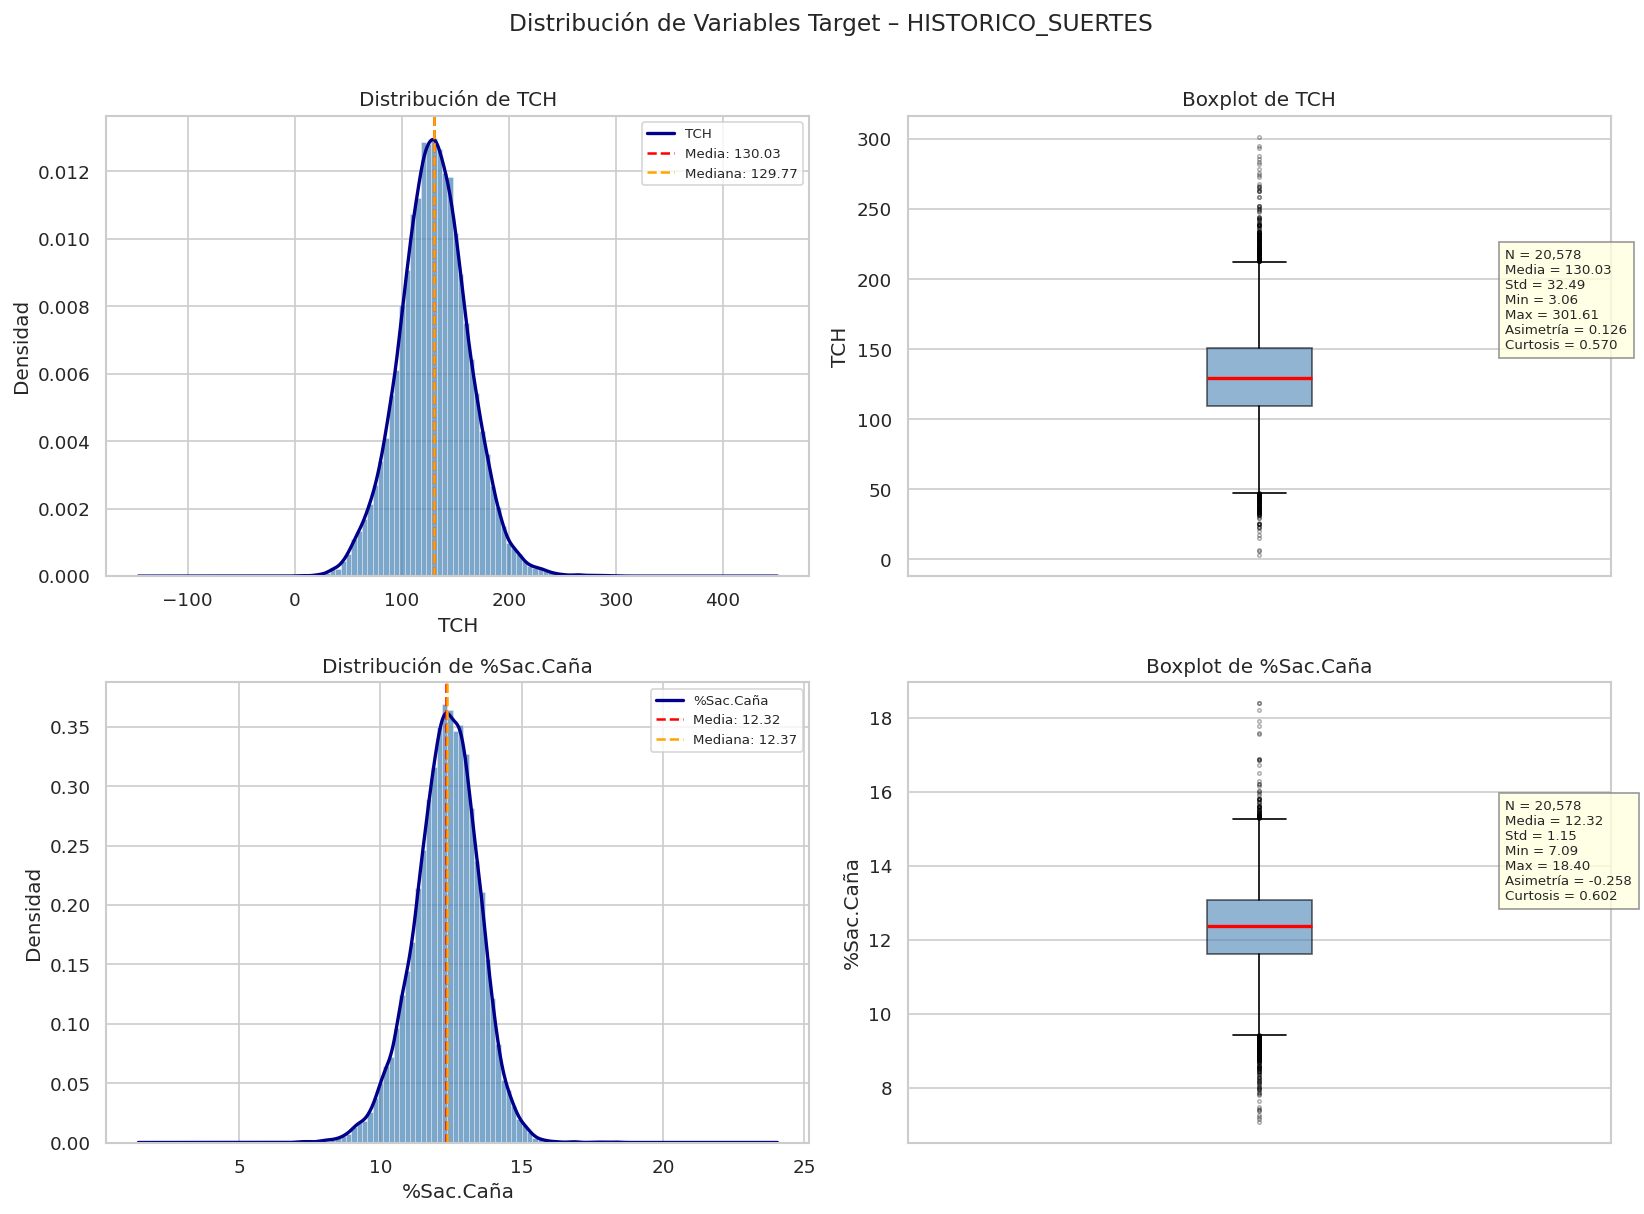

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, target in enumerate(['TCH', '%Sac.Caña']):
    datos = df_reg_clean[target].dropna()
    
    # Histograma + KDE
    ax1 = axes[i, 0]
    ax1.hist(datos, bins=60, color='steelblue', alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
    datos.plot.kde(ax=ax1, color='darkblue', linewidth=2)
    ax1.axvline(datos.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {datos.mean():.2f}')
    ax1.axvline(datos.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {datos.median():.2f}')
    ax1.set_title(f'Distribución de {target}')
    ax1.set_xlabel(target)
    ax1.set_ylabel('Densidad')
    ax1.legend(fontsize=8)
    
    # Boxplot
    ax2 = axes[i, 1]
    ax2.boxplot(datos, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    
    # Estadísticos en el boxplot
    stat = datos.describe()
    textstr = (f'N = {int(stat["count"]):,}\n'
               f'Media = {stat["mean"]:.2f}\n'
               f'Std = {stat["std"]:.2f}\n'
               f'Min = {stat["min"]:.2f}\n'
               f'Max = {stat["max"]:.2f}\n'
               f'Asimetría = {datos.skew():.3f}\n'
               f'Curtosis = {datos.kurtosis():.3f}')
    ax2.text(1.35, stat['75%'], textstr, fontsize=8,
             bbox=dict(facecolor='lightyellow', edgecolor='gray', alpha=0.8))
    ax2.set_title(f'Boxplot de {target}')
    ax2.set_ylabel(target)
    ax2.set_xticks([])

plt.suptitle('Distribución de Variables Target – HISTORICO_SUERTES', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Distribución de los Targets – BD_IPSA_1940

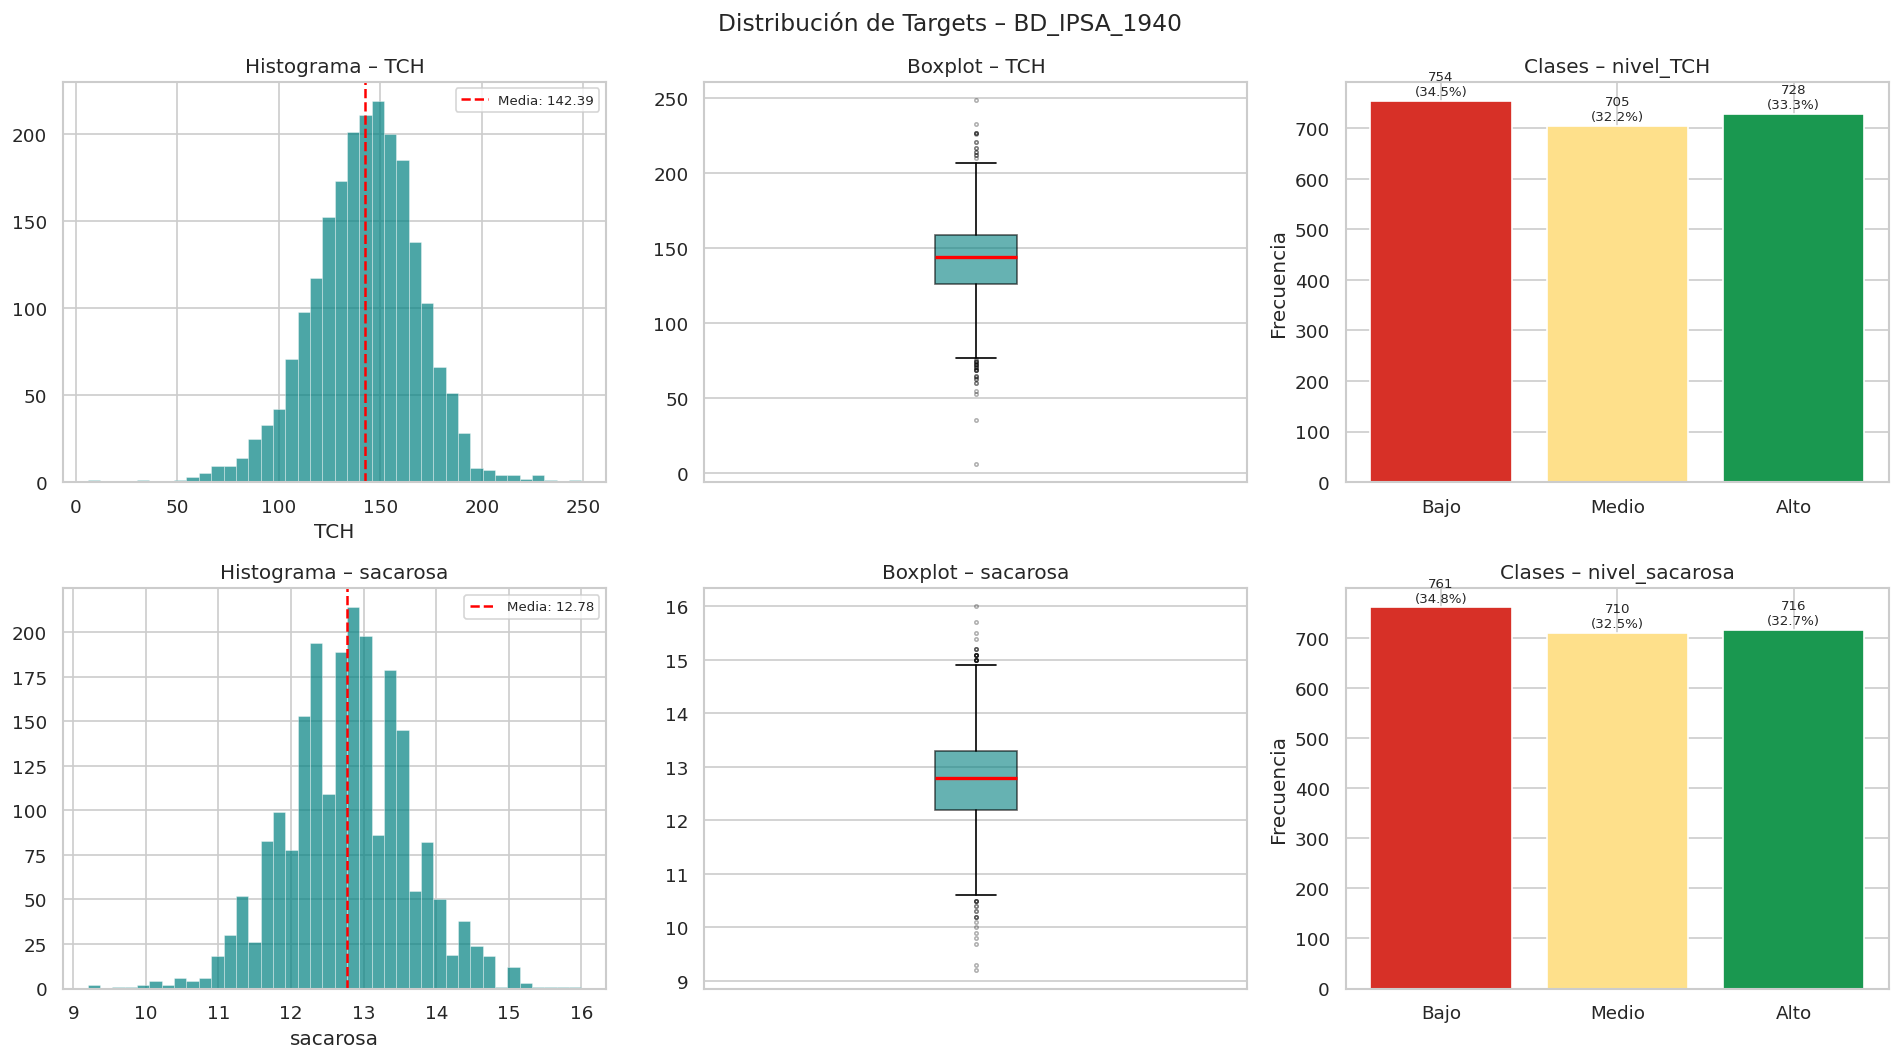

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, (target_raw, target_nivel) in enumerate([('TCH', 'nivel_TCH'), ('sacarosa', 'nivel_sacarosa')]):
    datos = df_clf_sel[target_raw]
    
    # Histograma
    ax1 = axes[i, 0]
    ax1.hist(datos, bins=40, color='teal', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax1.axvline(datos.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {datos.mean():.2f}')
    ax1.set_title(f'Histograma – {target_raw}')
    ax1.set_xlabel(target_raw)
    ax1.legend(fontsize=8)
    
    # Boxplot
    ax2 = axes[i, 1]
    ax2.boxplot(datos, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax2.set_title(f'Boxplot – {target_raw}')
    ax2.set_xticks([])
    
    # Distribución de clases
    ax3 = axes[i, 2]
    counts = df_clf_sel[target_nivel].value_counts().sort_index()
    colores = ['#d73027', '#fee08b', '#1a9850']
    bars = ax3.bar(counts.index, counts.values, color=colores, edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{v}\n({v/len(df_clf_sel)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8)
    ax3.set_title(f'Clases – {target_nivel}')
    ax3.set_ylabel('Frecuencia')

plt.suptitle('Distribución de Targets – BD_IPSA_1940', fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Detección de Outliers – Regla del IQR

In [12]:
def analisis_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct = n_outliers / len(df) * 100
    return {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Límite inferior': lim_inf, 'Límite superior': lim_sup,
        'N outliers': n_outliers, '% outliers': round(pct, 2)
    }

print('── Outliers en HISTORICO_SUERTES ──')
for t in ['TCH', '%Sac.Caña']:
    r = analisis_outliers(df_reg_clean, t)
    print(f"\n{t}:")
    for k, v in r.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print('\n── Outliers en BD_IPSA_1940 ──')
for t in ['TCH', 'sacarosa']:
    r = analisis_outliers(df_clf_sel, t)
    print(f"\n{t}:")
    for k, v in r.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

── Outliers en HISTORICO_SUERTES ──

TCH:
  Q1: 109.2199
  Q3: 150.5635
  IQR: 41.3436
  Límite inferior: 47.2045
  Límite superior: 212.5788
  N outliers: 293
  % outliers: 1.4200

%Sac.Caña:
  Q1: 11.6190
  Q3: 13.0875
  IQR: 1.4685
  Límite inferior: 9.4162
  Límite superior: 15.2903
  N outliers: 313
  % outliers: 1.5200

── Outliers en BD_IPSA_1940 ──

TCH:
  Q1: 126.0000
  Q3: 159.0000
  IQR: 33.0000
  Límite inferior: 76.5000
  Límite superior: 208.5000
  N outliers: 42
  % outliers: 1.9200

sacarosa:
  Q1: 12.2000
  Q3: 13.3000
  IQR: 1.1000
  Límite inferior: 10.5500
  Límite superior: 14.9500
  N outliers: 37
  % outliers: 1.6900


In [13]:
# Decisión sobre outliers de TCH en HISTORICO_SUERTES:
# Los valores extremos de TCH (ej. >400 ton/ha) son físicamente imposibles y representan
# errores de registro. Los aplicamos solo para el análisis de regresión.
# Para clasificación (BD_IPSA_1940), los datos son más limpios (rango 6-249).

for col in ['TCH', '%Sac.Caña']:
    Q1 = df_reg_clean[col].quantile(0.25)
    Q3 = df_reg_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 3.0 * IQR  # Usamos 3×IQR para conservar casos extremos reales
    lim_sup = Q3 + 3.0 * IQR  # (1.5×IQR sería demasiado agresivo en datos agrícolas)
    n_antes = len(df_reg_clean)
    df_reg_clean = df_reg_clean[
        (df_reg_clean[col] >= lim_inf) & (df_reg_clean[col] <= lim_sup)
    ]
    print(f'{col}: eliminados {n_antes - len(df_reg_clean)} registros fuera de [{lim_inf:.2f}, {lim_sup:.2f}]')

print(f'\nDataset final tras limpieza de outliers: {df_reg_clean.shape}')

TCH: eliminados 9 registros fuera de [-14.81, 274.59]
%Sac.Caña: eliminados 10 registros fuera de [7.21, 17.49]

Dataset final tras limpieza de outliers: (20559, 23)


### 6.4 Análisis de Relaciones – Variables Numéricas vs Targets (Regresión)

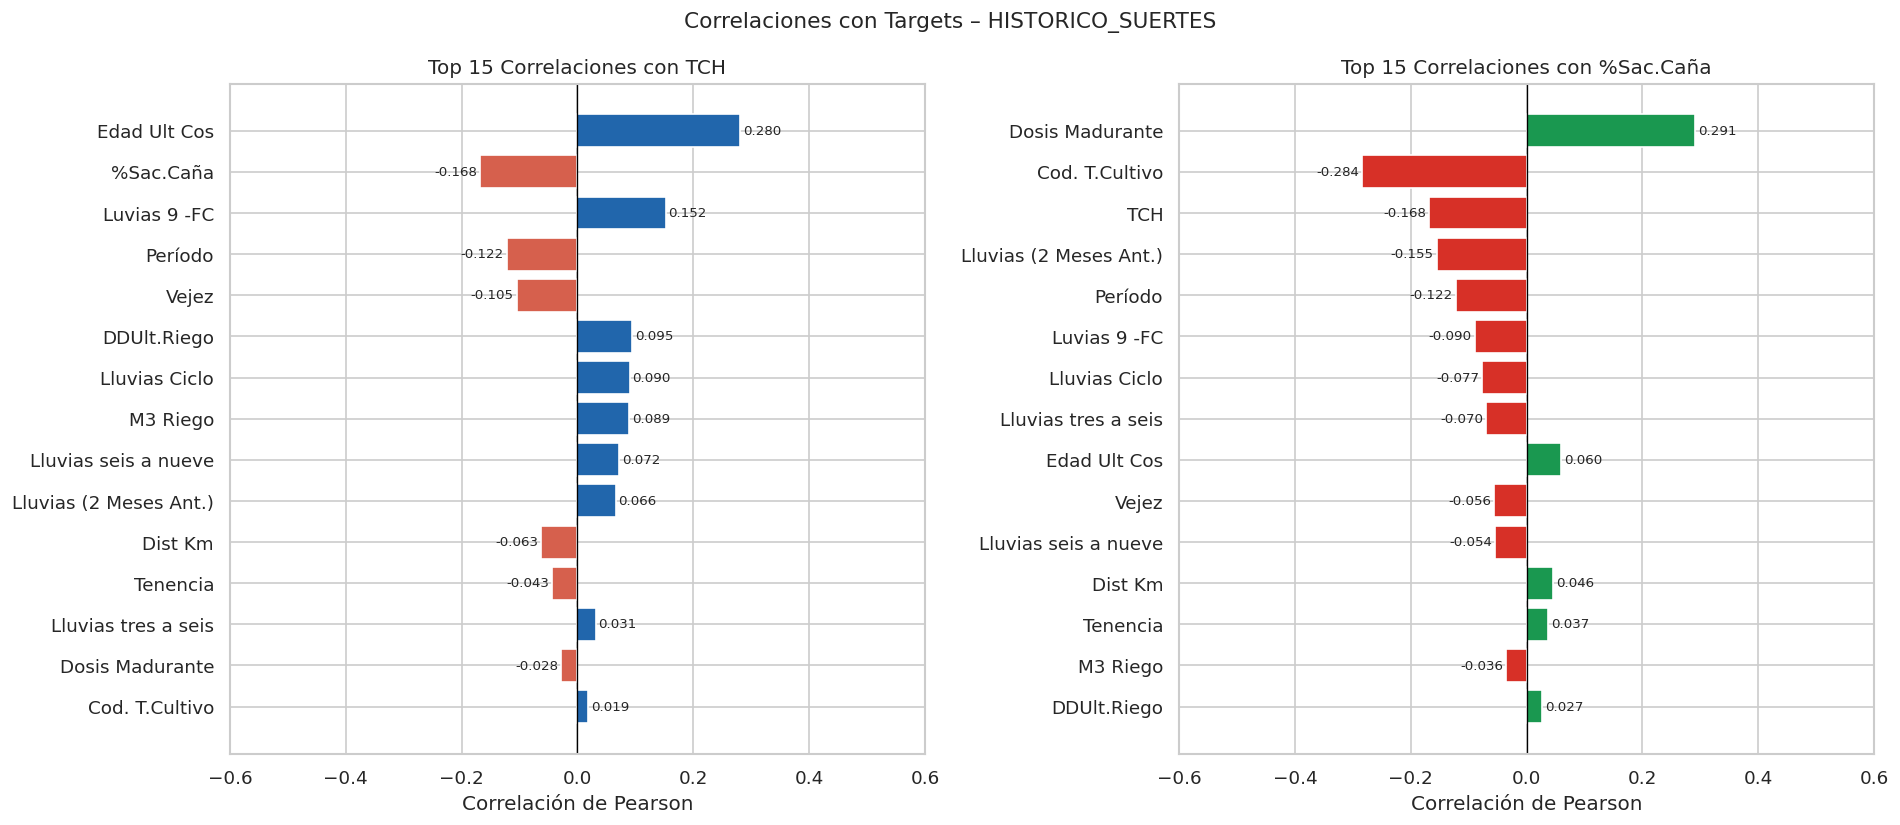

In [14]:
# Correlaciones de Pearson con los targets
num_cols_reg = df_reg_clean.select_dtypes(include='number').columns.tolist()
corr_tch = df_reg_clean[num_cols_reg].corr()['TCH'].drop('TCH').sort_values(key=abs, ascending=False)
corr_sac = df_reg_clean[num_cols_reg].corr()['%Sac.Caña'].drop('%Sac.Caña').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, corr, title, color_pos, color_neg in [
    (axes[0], corr_tch.head(15), 'Top 15 Correlaciones con TCH', '#2166ac', '#d6604d'),
    (axes[1], corr_sac.head(15), 'Top 15 Correlaciones con %Sac.Caña', '#1a9850', '#d73027')
]:
    colores = [color_pos if v > 0 else color_neg for v in corr.values]
    bars = ax.barh(corr.index[::-1], corr.values[::-1], color=colores[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, corr.values[::-1]):
        ax.text(
            bar.get_width() + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8
        )
    ax.set_title(title)
    ax.set_xlabel('Correlación de Pearson')
    ax.set_xlim(-0.6, 0.6)

plt.suptitle('Correlaciones con Targets – HISTORICO_SUERTES', fontsize=13)
plt.tight_layout()
plt.show()

### 6.5 Matriz de Correlación – Variables Numéricas

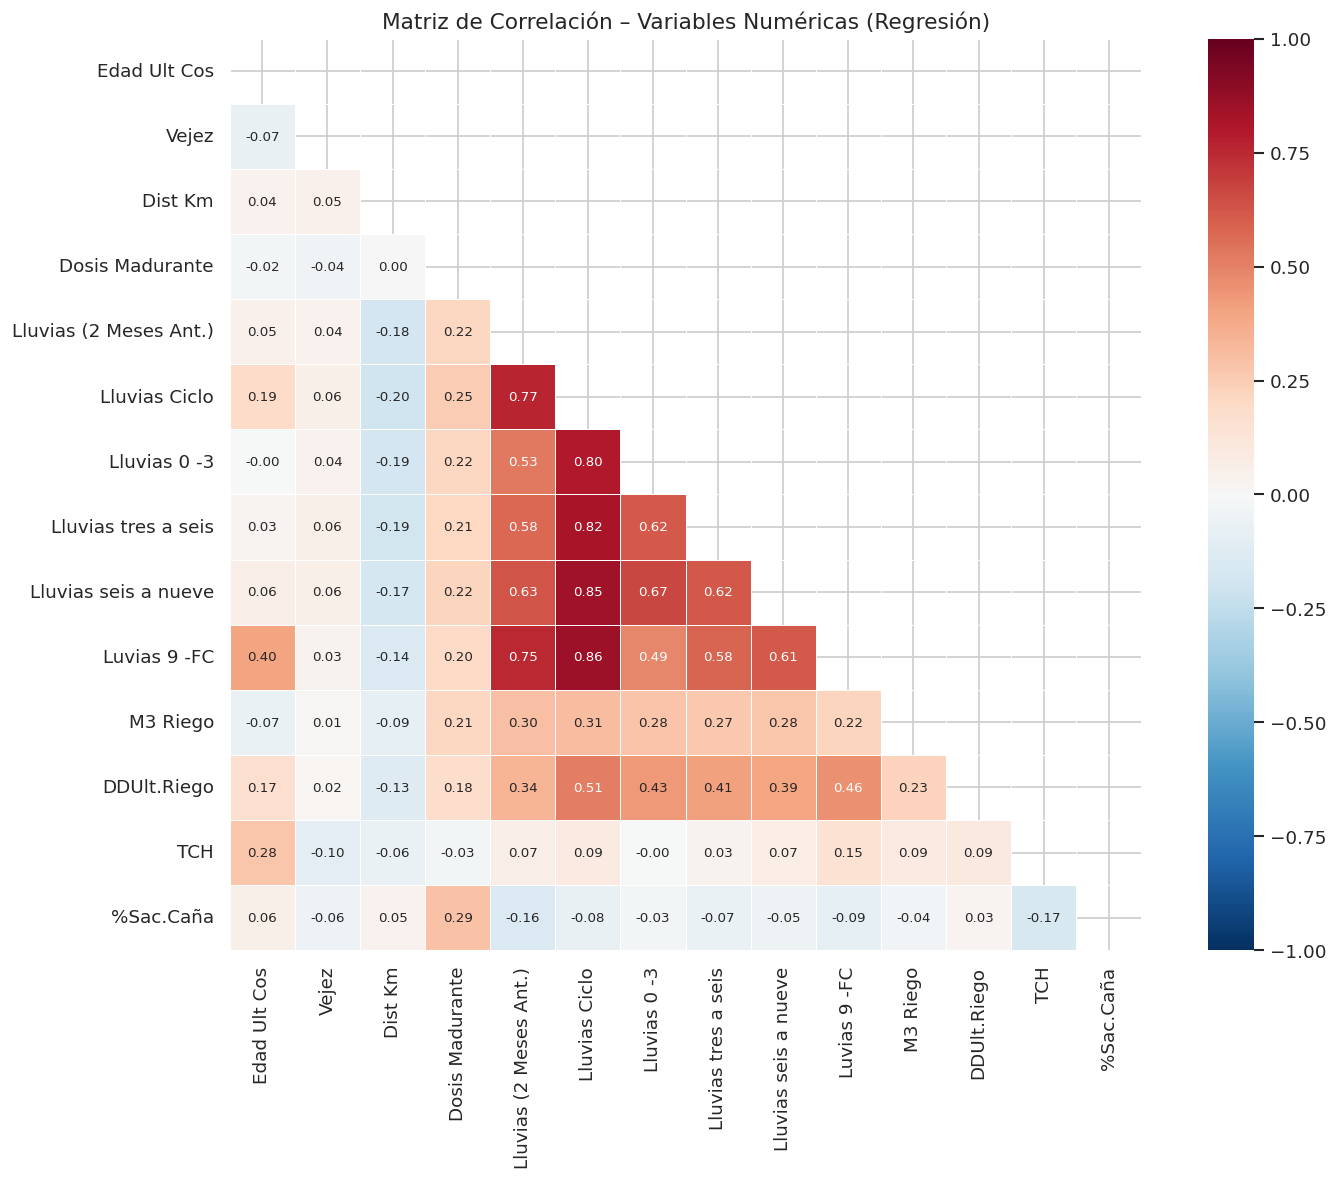

In [15]:
# Seleccionamos solo las variables numéricas del conjunto reducido para la matriz
num_features_reg = [
    'Edad Ult Cos', 'Vejez', 'Dist Km', 'Dosis Madurante',
    'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo', 'Lluvias 0 -3',
    'Lluvias tres a seis', 'Lluvias seis a nueve', 'Luvias 9 -FC',
    'M3 Riego', 'DDUlt.Riego', 'TCH', '%Sac.Caña'
]

corr_matrix = df_reg_clean[num_features_reg].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlación – Variables Numéricas (Regresión)', fontsize=13)
plt.tight_layout()
plt.show()

### 6.6 Gráficos de Dispersión – Relaciones Clave

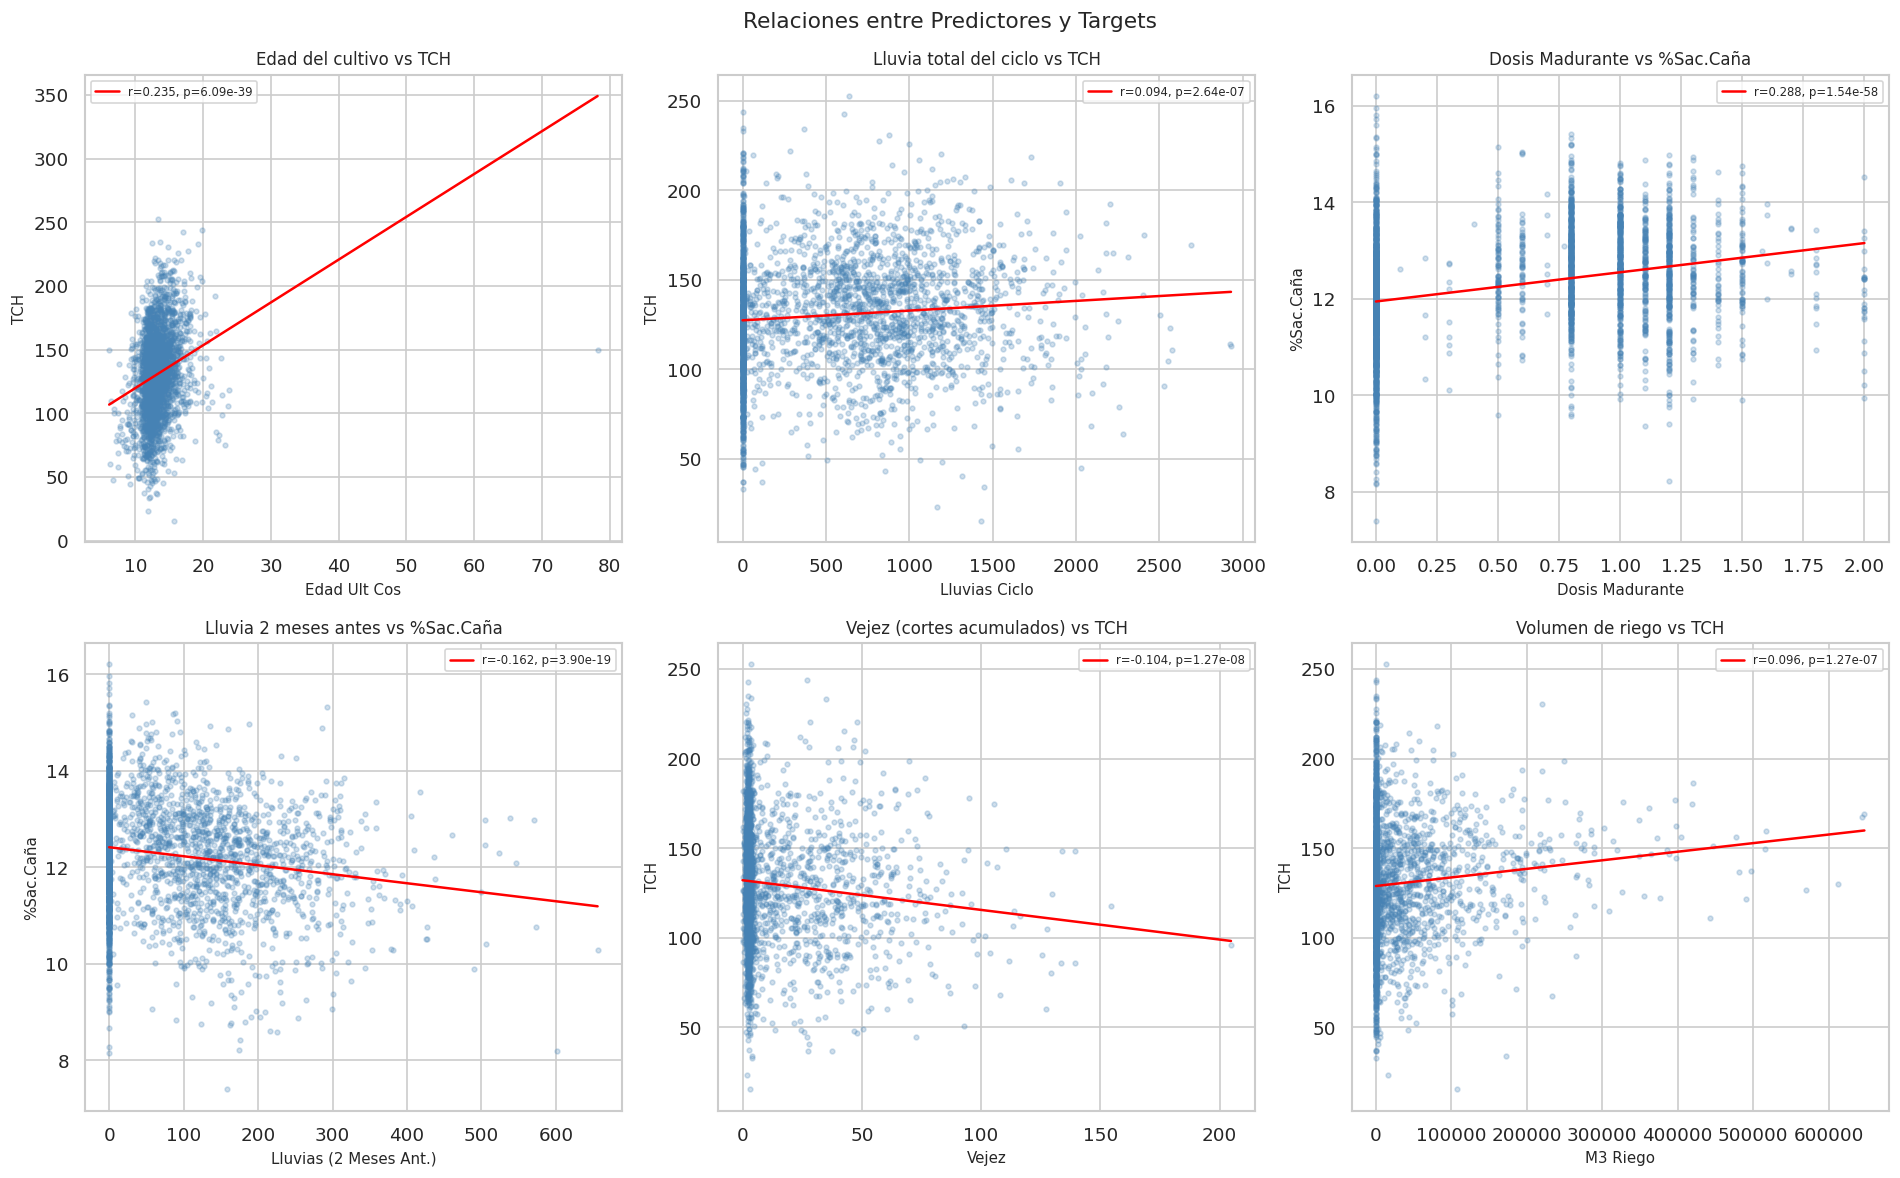

In [16]:
# Muestra aleatoria para que los scatterplots no estén saturados
sample = df_reg_clean.sample(n=min(3000, len(df_reg_clean)), random_state=SEED)

pares = [
    ('Edad Ult Cos', 'TCH', 'Edad del cultivo vs TCH'),
    ('Lluvias Ciclo', 'TCH', 'Lluvia total del ciclo vs TCH'),
    ('Dosis Madurante', '%Sac.Caña', 'Dosis Madurante vs %Sac.Caña'),
    ('Lluvias (2 Meses Ant.)', '%Sac.Caña', 'Lluvia 2 meses antes vs %Sac.Caña'),
    ('Vejez', 'TCH', 'Vejez (cortes acumulados) vs TCH'),
    ('M3 Riego', 'TCH', 'Volumen de riego vs TCH'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x, y, titulo) in zip(axes, pares):
    ax.scatter(sample[x], sample[y], alpha=0.25, s=8, color='steelblue')
    # Línea de tendencia
    datos_validos = sample[[x, y]].dropna()
    if len(datos_validos) > 10:
        m, b, r, p, _ = stats.linregress(datos_validos[x], datos_validos[y])
        xrng = np.linspace(datos_validos[x].min(), datos_validos[x].max(), 100)
        ax.plot(xrng, m*xrng + b, color='red', linewidth=1.5,
                label=f'r={r:.3f}, p={p:.2e}')
        ax.legend(fontsize=7)
    ax.set_xlabel(x, fontsize=9)
    ax.set_ylabel(y, fontsize=9)
    ax.set_title(titulo, fontsize=10)

plt.suptitle('Relaciones entre Predictores y Targets', fontsize=13)
plt.tight_layout()
plt.show()

### 6.7 TCH y %Sac.Caña por Variedad – Top 15 variedades

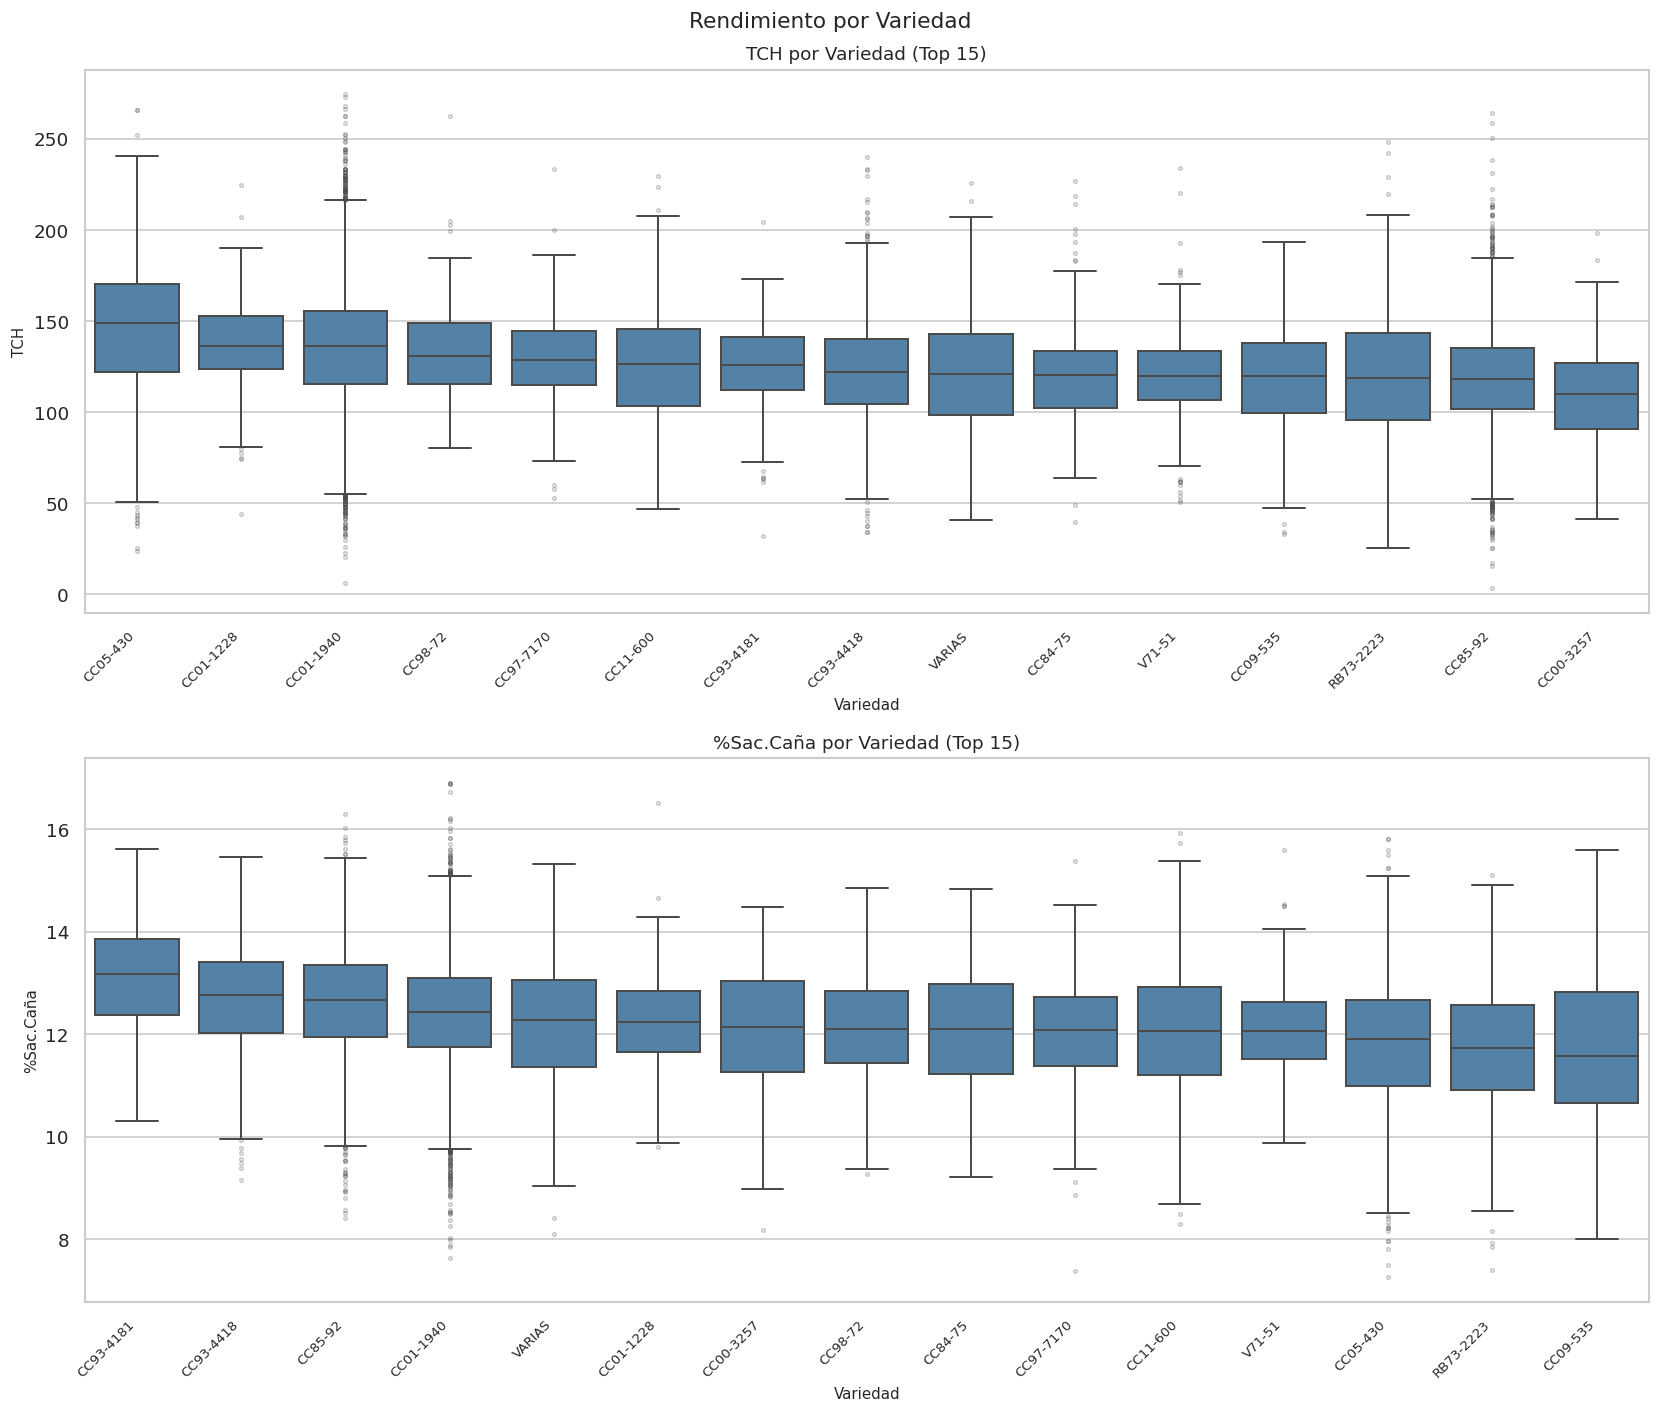

In [17]:
top_variedades = df_reg_clean['Variedad'].value_counts().head(15).index
df_top = df_reg_clean[df_reg_clean['Variedad'].isin(top_variedades)].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, target in zip(axes, ['TCH', '%Sac.Caña']):
    orden = df_top.groupby('Variedad')[target].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(
        data=df_top, x='Variedad', y=target, order=orden, ax=ax,
        color='steelblue', linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(f'{target} por Variedad (Top 15)', fontsize=11)
    ax.set_xlabel('Variedad', fontsize=9)
    ax.set_ylabel(target, fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.suptitle('Rendimiento por Variedad', fontsize=13)
plt.tight_layout()
plt.show()

### 6.8 EDA Dataset de Clasificación – BD_IPSA_1940

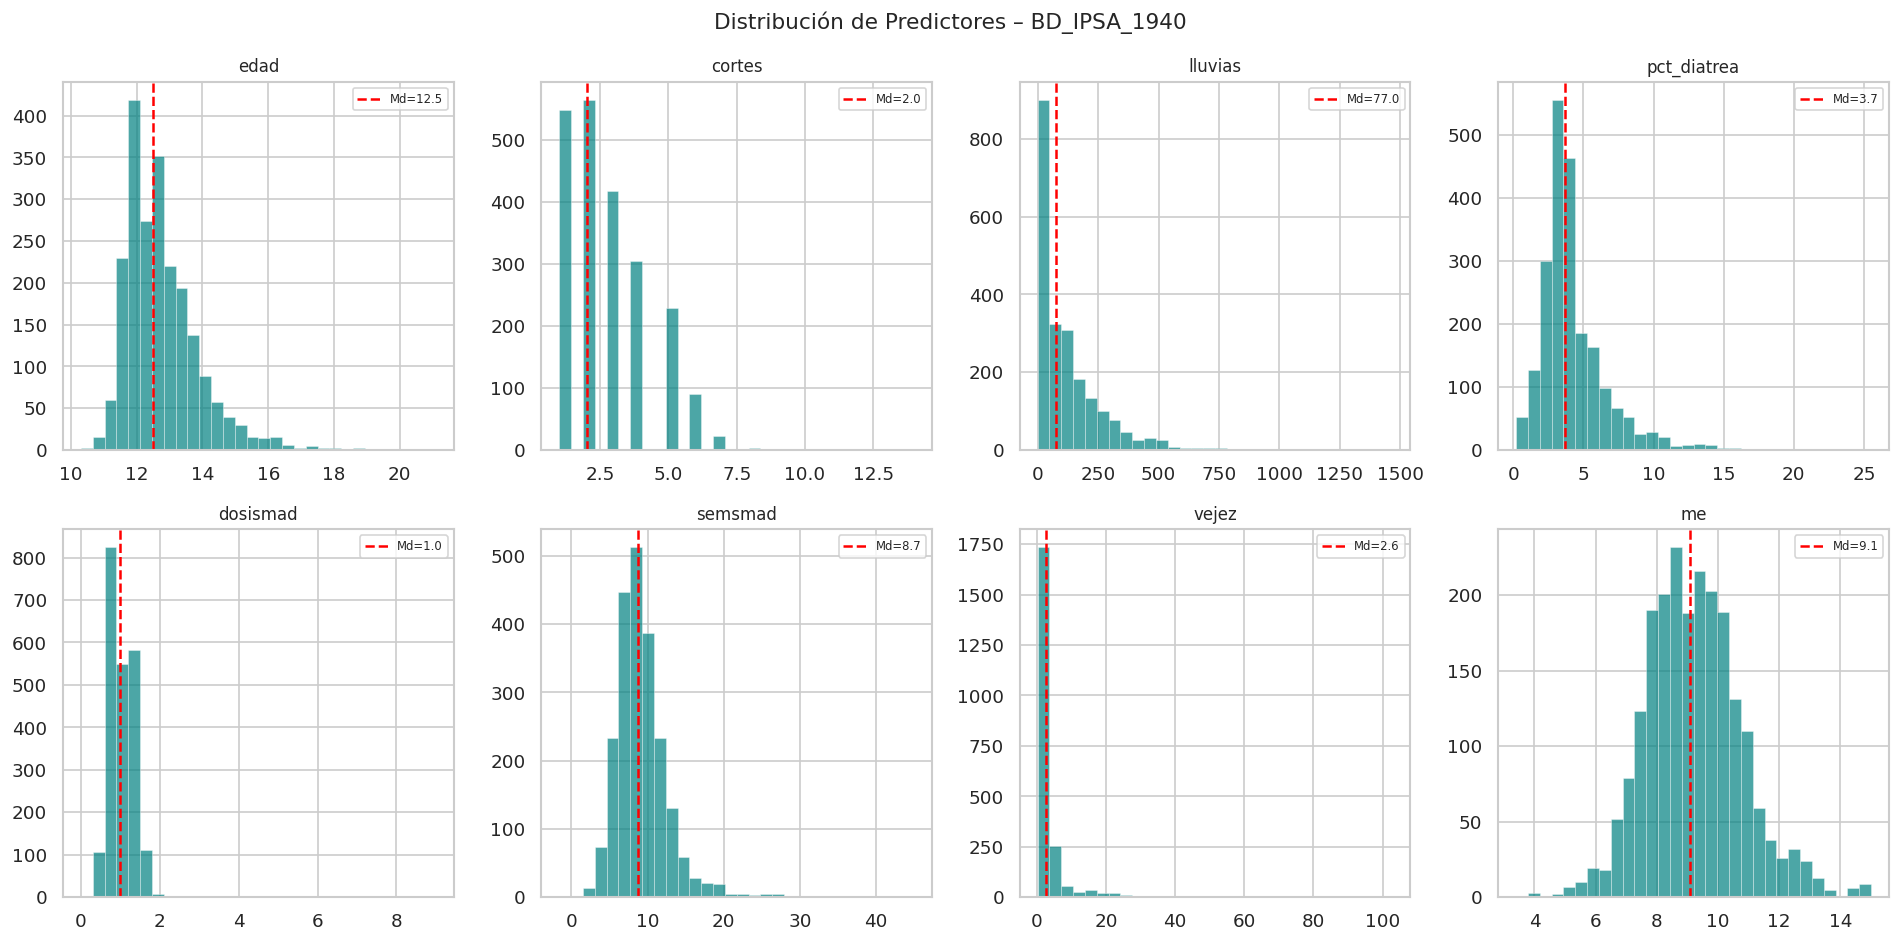

In [18]:
# Distribuciones de variables numéricas del dataset de clasificación
num_clf = ['edad', 'cortes', 'lluvias', 'pct_diatrea', 'dosismad', 'semsmad', 'vejez', 'me']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_clf):
    ax.hist(df_clf_sel[col], bins=30, color='teal', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(df_clf_sel[col].median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Md={df_clf_sel[col].median():.1f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Distribución de Predictores – BD_IPSA_1940', fontsize=13)
plt.tight_layout()
plt.show()

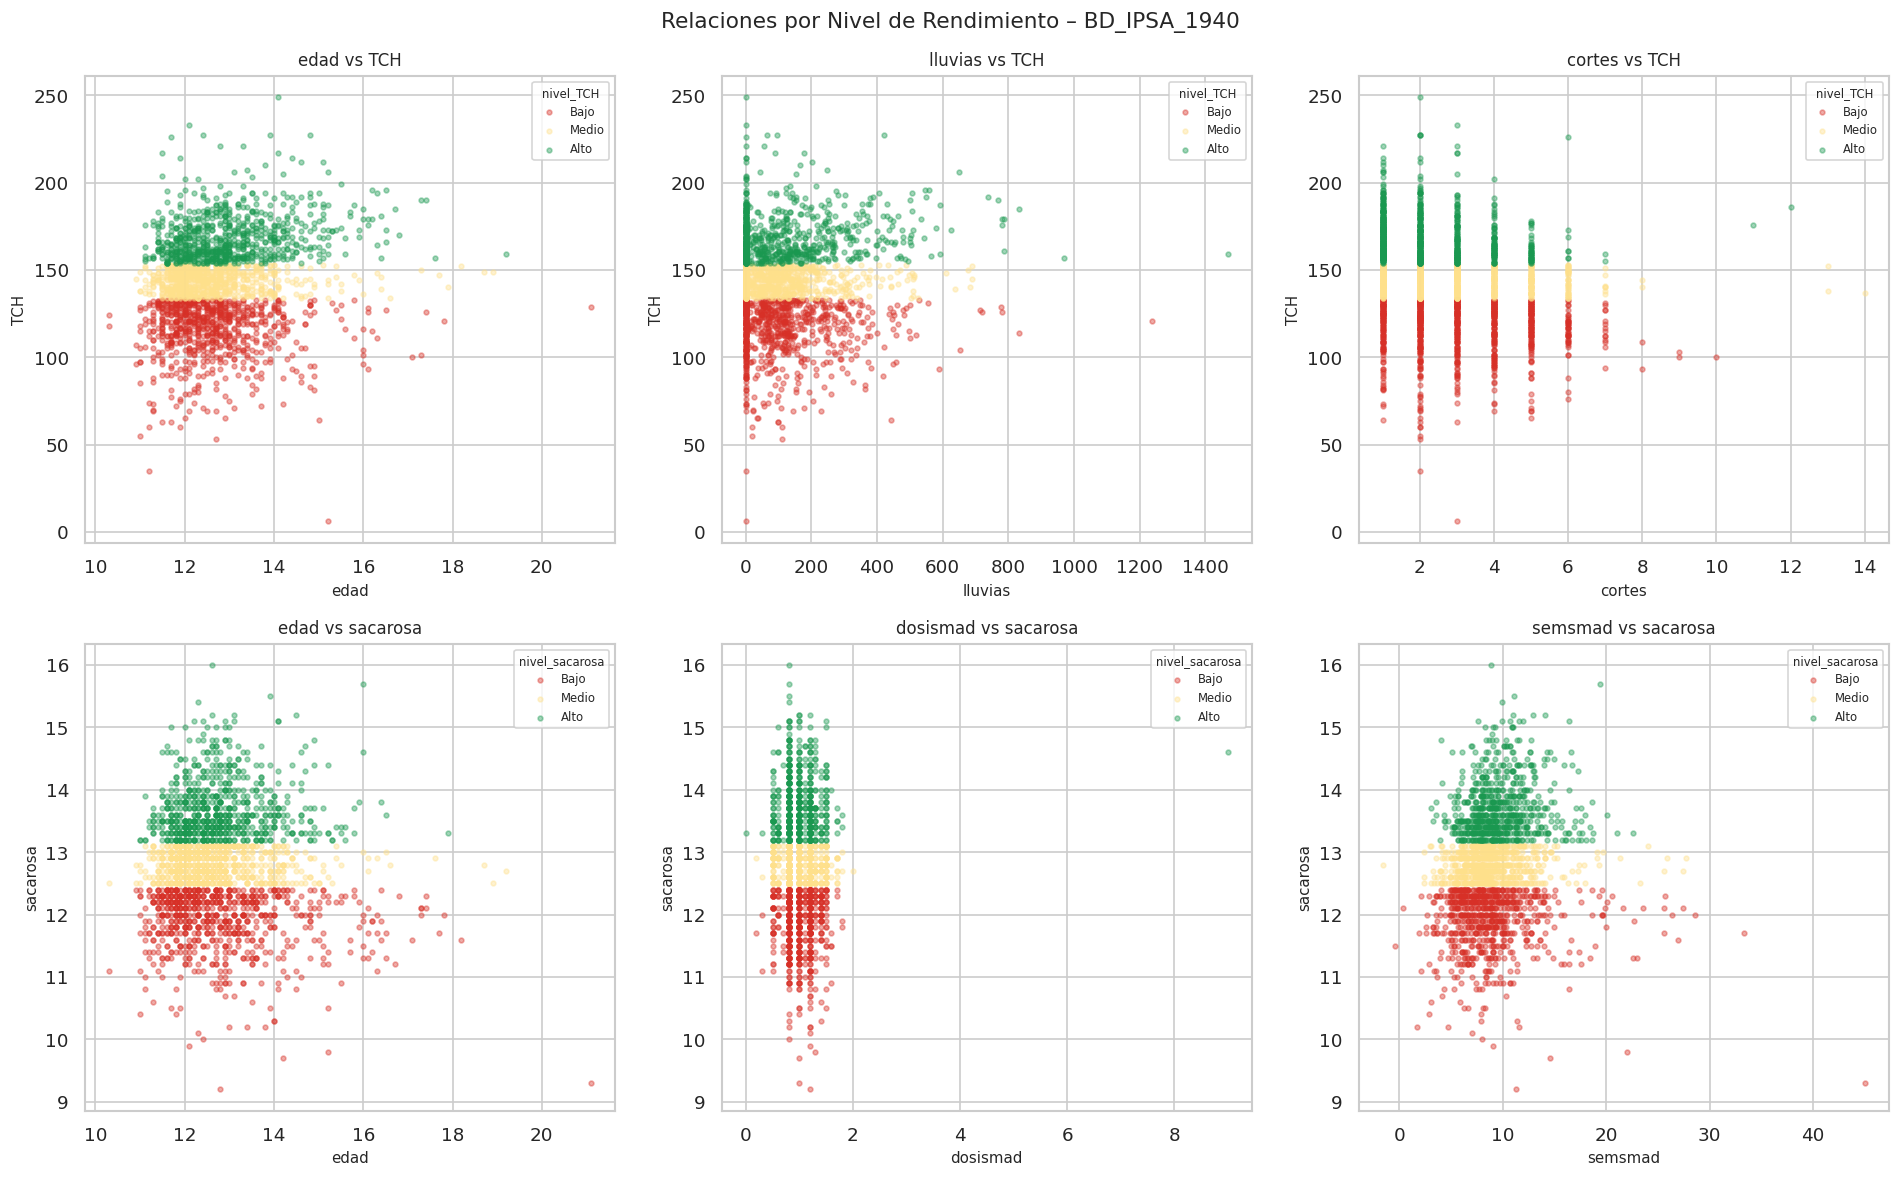

In [19]:
# Relaciones clave en clasificación
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

pares_clf = [
    ('edad', 'TCH', 'nivel_TCH'),
    ('lluvias', 'TCH', 'nivel_TCH'),
    ('cortes', 'TCH', 'nivel_TCH'),
    ('edad', 'sacarosa', 'nivel_sacarosa'),
    ('dosismad', 'sacarosa', 'nivel_sacarosa'),
    ('semsmad', 'sacarosa', 'nivel_sacarosa'),
]

palette = {'Bajo': '#d73027', 'Medio': '#fee08b', 'Alto': '#1a9850'}

for ax, (x, y, hue) in zip(axes.flatten(), pares_clf):
    for nivel, color in palette.items():
        mask = df_clf_sel[hue] == nivel
        ax.scatter(
            df_clf_sel.loc[mask, x], df_clf_sel.loc[mask, y],
            alpha=0.4, s=8, color=color, label=nivel
        )
    ax.set_xlabel(x, fontsize=9)
    ax.set_ylabel(y, fontsize=9)
    ax.set_title(f'{x} vs {y}', fontsize=10)
    ax.legend(fontsize=7, title=hue, title_fontsize=7)

plt.suptitle('Relaciones por Nivel de Rendimiento – BD_IPSA_1940', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Detección de Multicolinealidad – VIF

El VIF (Factor de Inflación de la Varianza) mide cuánto aumenta la varianza de un coeficiente de regresión debido a la multicolinealidad.

- **VIF < 5**: Aceptable
- **5 ≤ VIF < 10**: Multicolinealidad moderada – evaluar
- **VIF ≥ 10**: Multicolinealidad severa – eliminar o combinar

In [20]:
# VIF para variables numéricas con intercepto (statsmodels lo requiere para resultados correctos).
# Las 4 lluvias intermedias se excluyen porque por definición Lluvias Ciclo = suma de los 4 sub-periodos
# (colinealidad perfecta haría VIF=infinito y rompería el cálculo).
# Estrategia para los modelos:
#   - Regresión Lineal/Ridge: usar Lluvias Ciclo + Lluvias 2 Meses Ant. con regularización L2.
#   - Random Forest / XGBoost: incluir todas las variables (robustos a multicolinealidad).

vars_vif = [
    'Edad Ult Cos', 'Vejez', 'Dist Km', 'Dosis Madurante',
    'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo',
    'M3 Riego', 'DDUlt.Riego', 'Tenencia', 'Período'
]

df_vif = df_reg_clean[vars_vif].dropna().copy()
# Agregamos columna constante (intercepto) — requerido por variance_inflation_factor
X_vif = np.hstack([np.ones((len(df_vif), 1)), df_vif.values])

vif_data = pd.DataFrame({
    'Variable': vars_vif,
    # Saltamos índice 0 (intercepto), tomamos VIF de cada predictor
    'VIF': [variance_inflation_factor(X_vif, i + 1) for i in range(len(vars_vif))]
})
vif_data = vif_data.sort_values('VIF', ascending=False)

print('Factor de Inflación de la Varianza (VIF) – con intercepto:')
print(vif_data.to_string(index=False))

Factor de Inflación de la Varianza (VIF) – con intercepto:
              Variable      VIF
         Lluvias Ciclo 3.362711
Lluvias (2 Meses Ant.) 2.539336
              Tenencia 1.835717
           DDUlt.Riego 1.495845
              M3 Riego 1.272591
               Período 1.152991
       Dosis Madurante 1.141624
               Dist Km 1.141236
          Edad Ult Cos 1.126936
                 Vejez 1.037622


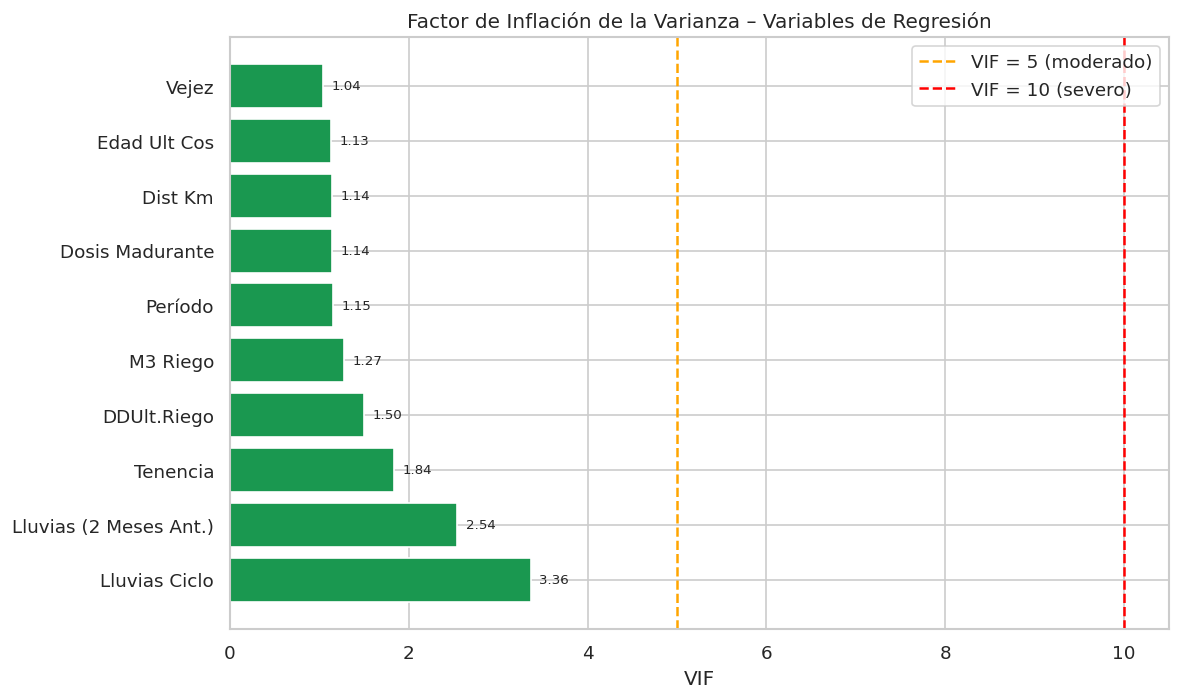


No hay variables con VIF ≥ 10. Multicolinealidad bajo control.


In [21]:
# Visualización VIF
fig, ax = plt.subplots(figsize=(10, 6))

colores_vif = vif_data['VIF'].apply(
    lambda x: '#d73027' if x >= 10 else ('#fc8d59' if x >= 5 else '#1a9850')
)

bars = ax.barh(vif_data['Variable'], vif_data['VIF'], color=colores_vif, edgecolor='white')
ax.axvline(5, color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (moderado)')
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='VIF = 10 (severo)')

for bar, val in zip(bars, vif_data['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

ax.set_xlabel('VIF')
ax.set_title('Factor de Inflación de la Varianza – Variables de Regresión')
ax.legend()
plt.tight_layout()
plt.show()

# Interpretación
high_vif = vif_data[vif_data['VIF'] >= 10]
if len(high_vif) > 0:
    print('\nVariables con VIF ≥ 10 (multicolinealidad severa):')
    print(high_vif.to_string(index=False))
    print('→ Acción: para Regresión Lineal considerar eliminar o combinar estas variables.')
    print('→ Random Forest y XGBoost son robustos a multicolinealidad, no requieren corrección.')
else:
    print('\nNo hay variables con VIF ≥ 10. Multicolinealidad bajo control.')

---
## 8. Preprocesamiento Final – Codificación de Categorías

In [22]:
# ── REGRESIÓN ──
# Codificamos variables categóricas con Label Encoding para análisis EDA
# En Tarea 3 usaremos One-Hot Encoding apropiado para cada modelo

df_reg_final = df_reg_clean.copy()
cat_cols_reg = df_reg_final.select_dtypes(include=['object', 'str']).columns.tolist()
print('Columnas categóricas en regresión:', cat_cols_reg)

le = LabelEncoder()
for col in cat_cols_reg:
    df_reg_final[col + '_cod'] = le.fit_transform(df_reg_final[col].astype(str))

# ── CLASIFICACIÓN ──
df_clf_final = df_clf_sel.copy()
cat_cols_clf = ['variedad', 'tipocorte', 'madurada']
for col in cat_cols_clf:
    df_clf_final[col + '_cod'] = le.fit_transform(df_clf_final[col].astype(str))

# Codificamos los targets de clasificación como numérico para sklearn
nivel_map = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
df_clf_final['nivel_TCH_num'] = df_clf_final['nivel_TCH'].map(nivel_map)
df_clf_final['nivel_sacarosa_num'] = df_clf_final['nivel_sacarosa'].map(nivel_map)

print(f'\nDataset regresión final: {df_reg_final.shape}')
print(f'Dataset clasificación final: {df_clf_final.shape}')

# Guardamos los datasets procesados
df_reg_final.to_csv('dataset_regresion_procesado.csv', index=False)
df_clf_final.to_csv('dataset_clasificacion_procesado.csv', index=False)
print('\nDatasets guardados correctamente.')

Columnas categóricas en regresión: ['Variedad', 'Suelo', 'Zona', 'Tipo Quema', 'T.Corte']

Dataset regresión final: (20559, 28)
Dataset clasificación final: (2187, 22)



Datasets guardados correctamente.


---
## 9. Resumen Ejecutivo del EDA

Este resumen concentra los hallazgos más importantes del análisis exploratorio, listos para incluir en el informe.

In [23]:
print('='*65)
print('RESUMEN EDA – TAREA 2')
print('='*65)

print('\n[1] DATASETS')
print(f'  HISTORICO_SUERTES: {df_reg_final.shape[0]:,} registros | {len(FEATURES_REG)} features seleccionadas')
print(f'  BD_IPSA_1940     : {df_clf_final.shape[0]:,} registros | {len(FEATURES_CLF)} features seleccionadas')

print('\n[2] TARGETS – REGRESIÓN (HISTORICO_SUERTES)')
for t in ['TCH', '%Sac.Caña']:
    d = df_reg_final[t]
    print(f'  {t}: media={d.mean():.2f}, std={d.std():.2f}, '
          f'min={d.min():.2f}, max={d.max():.2f}, asimetría={d.skew():.3f}')

print('\n[3] TARGETS – CLASIFICACIÓN (BD_IPSA_1940)')
for t in ['TCH', 'sacarosa']:
    d = df_clf_final[t]
    print(f'  {t}: media={d.mean():.2f}, std={d.std():.2f}, '
          f'min={d.min():.2f}, max={d.max():.2f}')

print('\n[4] DISTRIBUCIÓN DE CLASES (Clasificación)')
for nivel_col in ['nivel_TCH', 'nivel_sacarosa']:
    vc = df_clf_final[nivel_col].value_counts().sort_index()
    print(f'  {nivel_col}: ' + ' | '.join([f'{k}={v} ({v/len(df_clf_final)*100:.1f}%)' for k, v in vc.items()]))

print('\n[5] HALLAZGOS CLAVE')
print('  • TCH tiene distribución sesgada a la derecha (extremos de alta productividad).')
print('  • %Sac.Caña es más simétrica, con concentración entre 11-14%.')
print('  • Las lluvias del ciclo tienen correlación positiva con TCH (más agua = más biomasa).')
print('  • La lluvia en los 2 meses previos a cosecha tiene correlación NEGATIVA con %Sac.Caña')
print('    (el exceso de agua antes de cosecha diluye el contenido de azúcar).')
print('  • La variedad y la edad del cultivo son predictores discriminantes entre clases.')
print('  • Multicolinealidad esperada entre variables de lluvia por periodos solapados;')
print('    se manejará con regularización en regresión lineal y es irrelevante para RF/XGBoost.')
print('  • 0 nulos en BD_IPSA_1940 → no requiere imputación.')

print('\n[6] VARIABLES DESCARTADAS POR LEAKAGE')
print('  Brix, Pureza, %ATR, KATRHM, Rdto, TAH, TAHM, TCHM, TonUltCorte')
print('  (son métricas calculadas post-cosecha que dependen de los mismos targets)')

print('\n' + '='*65)
print('Tarea 2 completada. Datasets listos para modelamiento (Tarea 3).')
print('='*65)

RESUMEN EDA – TAREA 2

[1] DATASETS
  HISTORICO_SUERTES: 20,559 registros | 21 features seleccionadas
  BD_IPSA_1940     : 2,187 registros | 13 features seleccionadas

[2] TARGETS – REGRESIÓN (HISTORICO_SUERTES)
  TCH: media=129.97, std=32.33, min=3.06, max=274.39, asimetría=0.083
  %Sac.Caña: media=12.32, std=1.14, min=7.27, max=16.90, asimetría=-0.288

[3] TARGETS – CLASIFICACIÓN (BD_IPSA_1940)
  TCH: media=142.39, std=25.84, min=6.00, max=249.00
  sacarosa: media=12.78, std=0.85, min=9.20, max=16.00

[4] DISTRIBUCIÓN DE CLASES (Clasificación)
  nivel_TCH: Bajo=754 (34.5%) | Medio=705 (32.2%) | Alto=728 (33.3%)
  nivel_sacarosa: Bajo=761 (34.8%) | Medio=710 (32.5%) | Alto=716 (32.7%)

[5] HALLAZGOS CLAVE
  • TCH tiene distribución sesgada a la derecha (extremos de alta productividad).
  • %Sac.Caña es más simétrica, con concentración entre 11-14%.
  • Las lluvias del ciclo tienen correlación positiva con TCH (más agua = más biomasa).
  • La lluvia en los 2 meses previos a cosecha tie